# Solar heating due to shortwave forcing anomalies decomposed into that falling on sea ice versus open ocean LENS2

By Ali Siddiqui

August 2025

In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from matplotlib.gridspec import GridSpec
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools


import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

cf_xarray    : 0.8.2
xeofs        : 1.0.3
intake       : 0.7.0
pop_tools    : 2023.3.0
distributed  : 2023.6.0
numpy        : 1.23.5
cmocean      : 3.0.3
dask_jobqueue: 0.8.2
xarray       : 2023.6.0
cartopy      : 0.21.1
intake_esm   : 2023.6.14
regionmask   : 0.12.1
shapely      : 2.0.1
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
geopandas    : 0.13.2
matplotlib   : 3.7.1
pint_xarray  : 0.3
salem        : 0.3.10
seaborn      : 0.12.2



/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/1850018547.py:46: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

In [5]:
cluster = dask_jobqueue.PBSCluster(
    cores=1,  # The number of cores you want
    memory='50GB',  # Amount of memory
    processes=1,  # How many processes
    queue='casper',  # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='$TMPDIR',  # Use your local directory
    resource_spec='select=1:ncpus=1:mem=50GB',  # Specify resources
    account='NCGD0011',  # Input your project ID here
    walltime='08:00:00',  # Amount of wall time
    interface='ext'  # Interface to use
    )

cluster.scale(400)

# Assign the cluster to our Client
client = Client(cluster)

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:274: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

In [6]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:46813,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Total threads: 0
Started: 2 minutes ago,Total memory: 0 B


### Get the grid

In [7]:
import pop_tools
grid = pop_tools.get_grid('POP_gx1v7')
# grid_atm = pop_tools.get_grid('POP_tx0.1v3')
# grid_atm

### Using code available from Rodgers et al 2021 at https://github.com/kj-stein/CESM2-LE

In [8]:
VAR = ['fswdn','fswup','sialb','aice','SHF_QSW', 'fswabs'] #sithick : sea ice thickness sialb : sea ice albedo, aice : sea ice conc

scenarios=('HIST','SSP370')
members_cmip=('1001.001','1021.002','1041.003','1061.004','1081.005','1101.006','1121.007','1141.008','1161.009','1181.010',
              '1231.001','1231.002','1231.003','1231.004','1231.005','1231.006','1231.007','1231.008','1231.009','1231.010',
              '1251.001','1251.002','1251.003','1251.004','1251.005','1251.006','1251.007','1251.008','1251.009','1251.010',
              '1281.001','1281.002','1281.003','1281.004','1281.005','1281.006','1281.007','1281.008','1281.009','1281.010',
              '1301.001','1301.002','1301.003','1301.004','1301.005','1301.006','1301.007','1301.008','1301.009','1301.010')
members_smbb=('1011.001','1031.002','1051.003','1071.004','1091.005','1111.006','1131.007','1151.008','1171.009','1191.010',
              '1231.011','1231.012','1231.013','1231.014','1231.015','1231.016','1231.017','1231.018','1231.019','1231.020',
              '1251.011','1251.012','1251.013','1251.014','1251.015','1251.016','1251.017','1251.018','1251.019','1251.020',
              '1281.011','1281.012','1281.013','1281.014','1281.015','1281.016','1281.017','1281.018','1281.019','1281.020',
              '1301.011','1301.012','1301.013','1301.014','1301.015','1301.016','1301.017','1301.018','1301.019','1301.020')
members=members_cmip+members_smbb
ensembles = [ens for ens in range(len(members))]

In [9]:
exceptcv=['time','nlon','nlat','z_t','lat_aux_grid','transport_regions','moc_components','dz',*VAR]
def process_coords(ds, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
          
    if drop:
        return ds.drop(coord_vars)
    else:
        return ds.set_coords(coord_vars)

In [10]:
import glob

file_list=[]
for var in VAR :
    ens_files=[]
    for member in members :
        files=[]    
        for scenario in scenarios :
            comp,model,time='ice','cice.h','month_1'
            if var=='SHF_QSW': comp,model,time='ocn','pop.h','month_1'
            in_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/'+comp+'/proc/tseries/'+time+'/'+var+'/'
            #'/proj/jedwards/archive/b.e21.B'+scenario+'*.f09_g17.LE2-'+member+'/'+comp+'/proc/tseries/'+time+'/'
            
            fn = 'b.e21.B'+scenario+'*.f09_g17.LE2-'+member+'.'+model+'.'+var+'.*.nc'
            files += glob.glob(in_dir+fn)
            files = sorted(files)
        ens_files.append(files)
    file_list.append(ens_files) 

In [11]:
for i in range(len(VAR)):
    print(i,VAR[i],len(file_list[i][:]))

0 fswdn 100
1 fswup 100
2 sialb 100
3 aice 100
4 SHF_QSW 100
5 fswabs 100


In [12]:
ds_0=xr.open_mfdataset(file_list[0],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_1=xr.open_mfdataset(file_list[1],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_2=xr.open_mfdataset(file_list[2],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_3=xr.open_mfdataset(file_list[3],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_4=xr.open_mfdataset(file_list[4],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_5=xr.open_mfdataset(file_list[5],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)

In [13]:
# ds_3 = ds_3['SHF_QSW'].to_dataset(name='SHF_QSW')

### Cleaning

Correcting for the time dimension, renaming for convinience, and masking out the southern hemisphere

In [14]:
time = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

In [15]:
ds_0['time'] = time
ds_1['time'] = time
ds_2['time'] = time
ds_3['time'] = time
ds_4['time'] = time
ds_5['time'] = time

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/2276090470.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_0['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/2276090470.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be sil

In [16]:
ds_0 = ds_0.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_1 = ds_1.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_2 = ds_2.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_3 = ds_3.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_4 = ds_4.rename({'concat_dim':'ensemble'})
ds_5 = ds_5.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})


In [17]:
ds_0 = ds_0.where(grid.TLAT>0)
ds_1 = ds_1.where(grid.TLAT>0)
ds_2 = ds_2.where(grid.TLAT>0)
ds_3 = ds_3.where(grid.TLAT>0)
ds_4 = ds_4.where(grid.TLAT>0)
ds_5 = ds_5.where(grid.TLAT>0)

In [18]:
# ds_2['aice'] = ds_2['aice'].where(ds_2['aice']>0.15)

In [19]:
# Selectign our data from 1920 onwards

ds_0 = ds_0.sel(time=slice('1920-01','2101-01'))
ds_1 = ds_1.sel(time=slice('1920-01','2101-01'))
ds_2 = ds_2.sel(time=slice('1920-01','2101-01'))
ds_3 = ds_3.sel(time=slice('1920-01','2101-01'))
ds_4 = ds_4.sel(time=slice('1920-01','2101-01'))
ds_5 = ds_5.sel(time=slice('1920-01','2101-01'))


### Heating equation

Writing down the equation for change in solar insolation

\begin{equation}
    Q_{\downarrow}^\prime = \overline{Q_{sw}} \bigg(\underbrace{C^\prime (\alpha_w  -  \overline{\alpha_{i}})}_\text{I} - \underbrace{\overline{C}\alpha_{i}^\prime}_\text{II}  - \underbrace{(C^\prime \alpha_{i}^\prime)^\prime}_\text{III}\bigg)+  Q_{sw}^\prime \bigg(\underbrace{ 1- \alpha_w}_\text{IV} +  \underbrace{\overline{C} (\alpha_w - \overline{\alpha_i})}_\text{V}\bigg)  + \underbrace{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}_\text{VI} - \underbrace{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}_\text{VII} - \underbrace{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}_\text{VIII}.
\end{equation}


In [20]:
# writing down the variables that we're gonna use to construct the terms

#shortwave 
sw_avg = ds_0.fswdn.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
sw = ds_0.fswdn
sw_ref = sw.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
sw_change = sw.groupby('time.month') - sw_ref

# sea ice albedo
sialb = (ds_1.fswup/ds_0.fswdn).fillna(0)
alb_i_avg = sialb.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
alb_i = sialb
alb_i_ref = alb_i.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
alb_i_change = alb_i.groupby('time.month') - alb_i_ref

#seawater albedo
alb_w_avg = 0.07

# sea ice concentration
ds_3['aice'] = ds_3['aice'].fillna(0)
aice_avg = ds_3.aice.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')

aice = ds_3.aice
aice_ref = aice.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
aice_change = aice.groupby('time.month') - aice_ref

# sw_abs
sw_abs = (ds_5.fswabs*aice).fillna(0) + (ds_4.SHF_QSW).where(aice==0).fillna(0) + (ds_4.SHF_QSW)*(1-aice).where(aice>0).fillna(0)
sw_abs_ref = sw_abs.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
sw_abs_change = sw_abs.groupby('time.month') - sw_abs_ref


/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[

Creating the mask for area over which the heating is computed, e.g. mean September sea ice area during 1920-1950, similar to Holland et al 2015

In [21]:
area = grid.TAREA.where(grid.TLAT>66) # make this NH
# saice = aice.sel(time=slice('1920-01','1950-12')).groupby('time.month')[9].mean(dim=['time','ensemble'],skipna=True)
# area = area.where(saice>0)
area = area.where(ds_0.fswdn.sel(time='2020-06',ensemble=10).squeeze()>0)


### Absorbed shortwave $Q_{\downarrow}^\prime$

In [22]:
SW_abs = sw_abs

In [23]:
# area and concentration weighted value

SW_abs_num_ice = (SW_abs.where(aice>0.15)*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den_ice = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_ice = SW_abs_num_ice/SW_abs_den_ice

SW_abs_num_ocn = (SW_abs.where(aice<0.15)*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den_ocn = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_ocn = SW_abs_num_ocn/SW_abs_den_ocn

SW_abs_num = (SW_abs*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_sum = SW_abs_num/SW_abs_den

In [24]:
SW_abs_ocn = SW_abs_ocn.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 27.37 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [25]:
SW_abs_ice = SW_abs_ice.load()

In [26]:
SW_abs_sum = SW_abs_sum.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 27.13 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [27]:
SW_abs_sum

<xarray.DataArray (ensemble: 100, time: 2172)>
array([[6.68070394e-02, 1.60509894e+00, 1.12026893e+01, ...,
        8.25935796e+00, 4.95405670e-01, 4.67900767e-03],
       [6.77886304e-02, 1.70471364e+00, 1.07681037e+01, ...,
        8.19051925e+00, 4.86551570e-01, 4.55880569e-03],
       [6.43619016e-02, 1.56859516e+00, 1.09949344e+01, ...,
        7.68160325e+00, 4.83495372e-01, 3.97495438e-03],
       ...,
       [6.85873377e-02, 1.80039654e+00, 1.19394932e+01, ...,
        7.78632318e+00, 4.90939854e-01, 4.41042829e-03],
       [5.84851679e-02, 1.51393571e+00, 1.20068627e+01, ...,
        7.62235351e+00, 5.02798585e-01, 3.84968569e-03],
       [6.23467491e-02, 1.54172158e+00, 1.08994209e+01, ...,
        8.17612086e+00, 4.62698319e-01, 4.20122375e-03]])
Coordinates:
  * time      (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble  (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
Attributes:
    units:          W/m2
    long_name:      snow/ice/ocn absorbed solar flux (cpl)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [28]:
SW_abs_ice

<xarray.DataArray (ensemble: 100, time: 2172)>
array([[2.12061512e-02, 8.78401556e-01, 7.94747075e+00, ...,
        1.78477164e-04, 1.37818916e-04, 0.00000000e+00],
       [2.13335679e-02, 8.27462351e-01, 7.37087929e+00, ...,
        5.09422520e-03, 2.67248011e-06, 0.00000000e+00],
       [2.13265694e-02, 8.02056369e-01, 7.39847738e+00, ...,
        7.55582689e-03, 9.55387626e-05, 1.09835236e-05],
       ...,
       [1.94347316e-02, 8.37786256e-01, 7.11981798e+00, ...,
        0.00000000e+00, 9.29649071e-05, 0.00000000e+00],
       [2.32917187e-02, 8.96308365e-01, 7.69368678e+00, ...,
        0.00000000e+00, 0.00000000e+00, 1.57315478e-07],
       [2.26027259e-02, 8.84060563e-01, 7.76211083e+00, ...,
        5.64909718e-03, 0.00000000e+00, 6.23423565e-05]])
Coordinates:
  * time      (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble  (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
Attributes:
    units:          W/m2
    long_name:      snow/ice/ocn absorbed solar flux (cpl)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [29]:
ds_sw_abs = xr.merge([SW_abs_sum.to_dataset(name='sw_abs'),
                     SW_abs_ocn.to_dataset(name='sw_abs_ocn'),
                     SW_abs_ice.to_dataset(name='sw_abs_ice')])  
ds_sw_abs

<xarray.Dataset>
Dimensions:     (time: 2172, ensemble: 100)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble    (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
Data variables:
    sw_abs      (ensemble, time) float64 0.06681 1.605 11.2 ... 0.4627 0.004201
    sw_abs_ocn  (ensemble, time) float64 0.0456 0.7267 3.255 ... 0.4627 0.004139
    sw_abs_ice  (ensemble, time) float64 0.02121 0.8784 7.947 ... 0.0 6.234e-05

In [30]:
ds_sw_abs.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/SW_absorbed_LENS2.nc')

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.48 µs


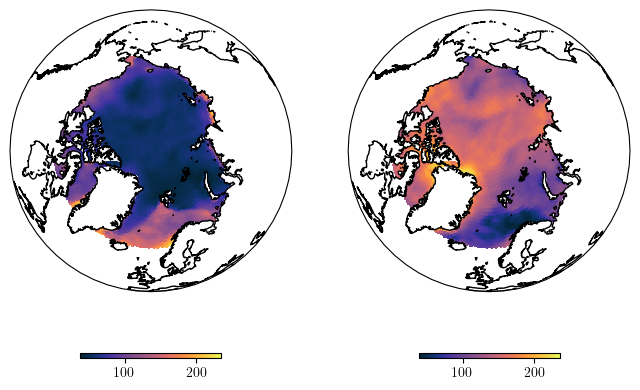

In [31]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
ax = ax.flatten()

cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (sw_abs).where(area>66).sel(time='2020-06',ensemble=10).squeeze(), 
                    cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())
ax[1].pcolormesh(grid.TLONG, grid.TLAT, (ds_0.fswdn).where(area>66).sel(time='2020-06',ensemble=10).squeeze(),
                   cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())
# ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

for i in range(2):
    ax[i].coastlines()
    # ax[i].add_feature(land_50m, facecolor='grey')

# Draw the colorbar
    cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# cbar.set_ticks(np.linspace(0,1,5))
# cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# cbar.ax.xaxis.set_label_position('bottom')
# cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# ax.set_title('September 2020')

# plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

### IV = $Q_{sw}^\prime ( 1- \alpha_w)$


In [32]:
I_V = sw_change*(1-alb_w_avg)

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.01 µs


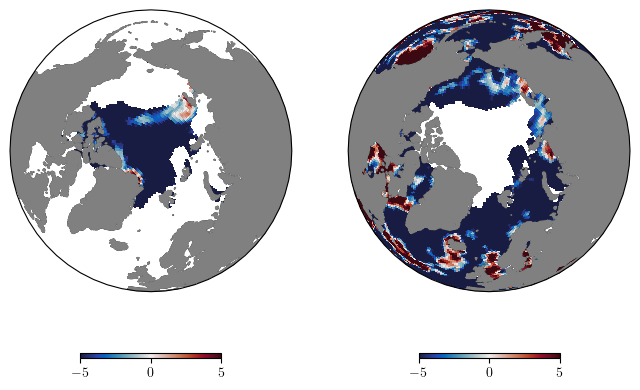

In [33]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
ax = ax.flatten()

cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (I_V).where(aice>0.15).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
ax[1].pcolormesh(grid.TLONG, grid.TLAT, (I_V).where(aice<0.15).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
# ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

for i in range(2):
    ax[i].coastlines()
    ax[i].add_feature(land_50m, facecolor='grey')

# Draw the colorbar
    cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# cbar.set_ticks(np.linspace(0,1,5))
# cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# cbar.ax.xaxis.set_label_position('bottom')
# cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# ax.set_title('September 2020')

# plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

In [34]:
# area and concentration weighted value
I_V_num_ice = (I_V.where(aice>0.15)*area).sum(('nlat','nlon'))
I_V_den_ice = (area).sum(('nlat','nlon'))
I_V_ice = I_V_num_ice/I_V_den_ice

I_V_num_ocn = (I_V.where(aice<0.15)*area).sum(('nlat','nlon'))
I_V_den_ocn = (area).sum(('nlat','nlon'))
I_V_ocn = I_V_num_ocn/I_V_den_ocn

I_V_num = (I_V*area).sum(('nlat','nlon'))
I_V_den = (area).sum(('nlat','nlon'))

I_V_sum = I_V_num/I_V_den

In [35]:
I_V_sum_ice = I_V_ice.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 21.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [36]:
I_V_sum_ocn = I_V_ocn.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 21.89 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [37]:
# I_V_sum = I_V_sum.load()

In [38]:
# fig, ax  = plt.subplots(figsize=(10,5))

# for ensemble in I_V_sum.ensemble:
#     ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
#     ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
#     ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
#     ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


# ax.tick_params(which='both',
#            labelcolor='k', 
#            labelsize=16, 
#            direction='inout',
#            width=1,
#            length=10,
#            pad=10)

# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
# ax.grid(alpha=0.2)
# ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

# ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
#             I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# # ax.set_ylim(-80,80)

# ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# # plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

In [39]:
# fig, ax  = plt.subplots(figsize=(10,5))

# for ensemble in I_V_sum.ensemble:
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


# ax.tick_params(which='both',
#            labelcolor='k', 
#            labelsize=16, 
#            direction='inout',
#            width=1,
#            length=10,
#            pad=10)

# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
# ax.grid(alpha=0.2)
# ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

# ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
#             I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# # ax.set_ylim(-80,80)

# ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# # plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

In [40]:
# fig, ax  = plt.subplots(figsize=(10,5))

# for ensemble in I_V_sum.ensemble:
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
#     ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
# ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


# ax.tick_params(which='both',
#            labelcolor='k', 
#            labelsize=16, 
#            direction='inout',
#            width=1,
#            length=10,
#            pad=10)

# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
# ax.grid(alpha=0.2)
# ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

# ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
#             I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# # ax.set_ylim(-80,80)

# ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# # plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

### V = $Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i}) $

In [41]:
V = sw_change.groupby('time.month')*(aice_avg*(alb_w_avg-alb_i_avg))

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [42]:
# # area and concentration weighted value
# V_num = (V*area).sum(('nlat','nlon'))
# V_den = (area).sum(('nlat','nlon'))
# V_sum = V_num/V_den

In [43]:
# area and concentration weighted value
V_num_ice = (V.where(aice>0.15)*area).sum(('nlat','nlon'))
V_den_ice = (area).sum(('nlat','nlon'))
V_ice = V_num_ice/V_den_ice

V_num_ocn = (V.where(aice<0.15)*area).sum(('nlat','nlon'))
V_den_ocn = (area).sum(('nlat','nlon'))
V_ocn = V_num_ocn/V_den_ocn

V_num = (V*area).sum(('nlat','nlon'))
V_den = (area).sum(('nlat','nlon'))
V_sum = V_num/V_den

In [44]:
V_sum_ice = V_ice.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 27.25 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [45]:
V_sum_ocn = V_ocn.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 27.25 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [46]:
# V_sum = V_sum.load()

In [47]:
# %time

# name='NearsidePerspective'
# proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# # Define the figure and each axis for the 3 rows and 3 columns
# fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
# ax = ax.flatten()

# cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (aice*V).where(saice>0).sel(time='2020-09',ensemble=10).squeeze(), 
#                    vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
# ax[1].pcolormesh(grid.TLONG, grid.TLAT, ((1-aice)*V).where(saice>0).sel(time='2020-09',ensemble=10).squeeze(), 
#                    vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
# # ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# # ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

# for i in range(2):
#     ax[i].coastlines()
#     ax[i].add_feature(land_50m, facecolor='grey')

# # Draw the colorbar
#     cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# # cbar.set_ticks(np.linspace(0,1,5))
# # cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# # cbar.ax.xaxis.set_label_position('bottom')
# # cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# # ax.set_title('September 2020')

# # plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

In [48]:
# V_sum = V_sum.load()

In [49]:
# fig, ax  = plt.subplots(figsize=(10,5))

# for ensemble in V_sum.ensemble:
#     ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
#     ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
#     ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
#     ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
# ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


# ax.tick_params(which='both',
#            labelcolor='k', 
#            labelsize=16, 
#            direction='inout',
#            width=1,
#            length=10,
#            pad=10)

# ax.xaxis.set_minor_locator(AutoMinorLocator())
# ax.yaxis.set_minor_locator(AutoMinorLocator())
# ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
# ax.grid(alpha=0.2)
# ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

# ax.set_xlim(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
#             V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))



# ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i})} $ [W/m$^2$]', fontsize=16)

# # plt.savefig('figs/term_5.png', format='png', bbox_inches='tight', dpi=300)

### Saving the terms

In [50]:
q_prime_ice = I_V_sum_ice + V_sum_ice
q_prime_ocn = I_V_sum_ocn + V_sum_ocn

In [51]:
ds_q_prime = xr.merge([q_prime_ice.to_dataset(name=('q_prime_ice')), q_prime_ocn.to_dataset(name=('q_prime_ocn'))])
ds_q_prime

<xarray.Dataset>
Dimensions:      (time: 2172, ensemble: 100)
Coordinates:
  * time         (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble     (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    month        (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    q_prime_ice  (ensemble, time) float64 -0.0007586 0.05716 ... 0.0 -7.6e-06
    q_prime_ocn  (ensemble, time) float64 0.003109 -0.04135 ... 0.0001177

In [52]:
ds_q_prime.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_1920_1950_LENS2.nc')

In [53]:
# client.close()

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/1592913497.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(months)
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/1592913497.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(months)
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_69059/1592913497.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(months)


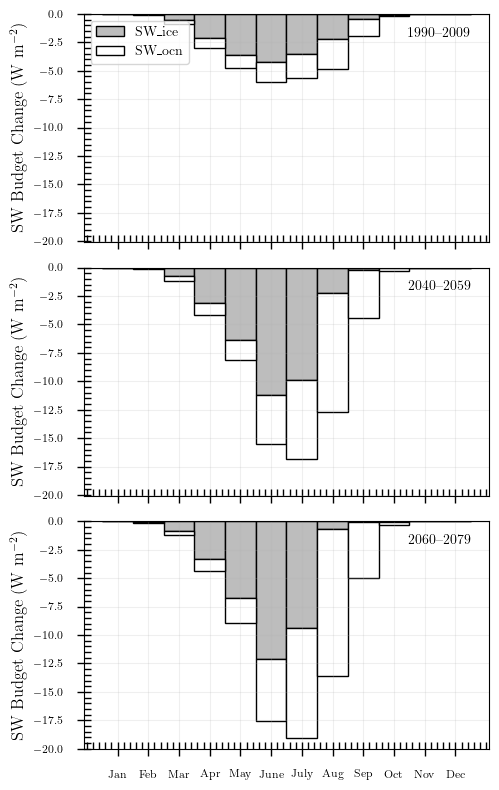

In [54]:
months = ('Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec')
colors = {
    "SW_ice": "#bdbdbd",
    "SW_ocn": "#FFFFFF"}
# Define time periods and titles
time_periods = [
    ('1990-01', '2009-12'),
    ('2040-01', '2059-12'),
    ('2060-01', '2079-12')
]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(5, 8), sharex=True, sharey=True)

for ax, (start, end) in zip(axes, time_periods):
    # Get data for each time period
    # incoming_SW = ds_new['IV'].sel(time=slice(start, end)).groupby('time.month').mean(dim=['ensemble', 'time'])
    SW_ice = ds_q_prime['q_prime_ice'].sel(time=slice(start, end)).groupby('time.month').mean(dim=['ensemble', 'time'])
    SW_ocn = ds_q_prime['q_prime_ocn'].sel(time=slice(start, end)).groupby('time.month').mean(dim=['ensemble', 'time'])

    contributions = {
        # "incoming SW": incoming_SW.values,
        "SW_ice": SW_ice.values,
        "SW_ocn": SW_ocn.values
    }

    width = 1.0
    bottom_pos = np.zeros(12)
    bottom_neg = np.zeros(12)

    for label in ["SW_ice", "SW_ocn"]:
        values = contributions[label]
        bar_bottom = np.where(values >= 0, bottom_pos, bottom_neg)
        ax.bar(months, values, width, label=label, bottom=bar_bottom, color=colors[label], edgecolor='black')
        bottom_pos += np.where(values >= 0, values, 0)
        bottom_neg += np.where(values < 0, values, 0)

    # ax.set_title(title, fontsize=12)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticklabels(months)
    ax.tick_params(which='both',
                   labelcolor='k',
                   labelsize=8,
                   direction='inout',
                   width=1,
                   length=10,
                   pad=10)

     # Add time period label
    start_year = start[:4]
    end_year = end[:4]
    ax.text(0.8, 0.9, f"{start_year}–{end_year}", transform=ax.transAxes)
    
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax.grid(alpha=0.2)

    ax.set_ylabel(r'SW Budget Change (W m$^{-2}$)', fontsize=12)
    
axes[0].legend(loc='upper left', fontsize=10)
# axes[0].set_ylim(-20,10)
# axes[1].set_ylim(-20,10)
# axes[2].set_ylim(-20,10)


plt.tight_layout()
# plt.savefig('figs/q_prime_decomposition.png', format='png', bbox_inches='tight', dpi=300)
